Please make sure you have read the [Getting Started page](https://pyrealm.readthedocs.io/en/latest/users/getting_started.html) before attempting to run this notebook.

Please make sure you have read the [Getting Started page](https://pyrealm.readthedocs.io/en/latest/users/getting_started.html) before attempting to run this notebook.

# Photosynthetic environment

The P Model is a model of carbon capture and water use by plants. There are six core
forcing variables that define the photosynthetic environment of the plant:

* the temperature (`tc`, °C),
* the vapor pressure deficit (`vpd`, Pa),
* the atmospheric $\ce{CO2}$ concentration (`co2`, ppm), and
* the atmospheric pressure (`patm`, Pa),
* the fraction of absorbed photosynthetically active radiation ($f_{APAR}$, `fapar`,
unitless), and
* the photosynthetic photon flux density (PPFD, `ppfd`, µmol m-2 s-1)

Those forcing variables are then used to calculate further variables that capture
the [photosynthetic environment](https://pyrealm.readthedocs.io/en/latest/users/pmodel/shared_components/photosynthetic_environment.html) of a leaf. These are:

1. the photorespiratory compensation point ($\Gamma^*$, Pascals),
2. the Michaelis-Menten coefficient for photosynthesis ($K_{mm}$, Pascals),
3. the relative viscosity of water, given a standard at 25°C ($\eta^*$, unitless),
4. the partial pressure of $\ce{CO2}$ in ambient air ($c_a$, Pascals), and
5. the absorbed irradiance ($I_{abs}$, µmol m-2 s-1)

The descriptions below show the typical ranges of these values under common
environmental inputs along with links to the more detailed documentation of the key
functions.


In [1]:
# This code loads required packages and then creates a representative range of
# values of the core variables to use in function plots.
#
# Note that the ranges are created (`_1d`) but are also cast to two dimensional
# arrays of repeating values (`_2d`) to generate response surfaces for functions
# with multuple inputs.

import numpy as np
from matplotlib import pyplot

from pyrealm.constants import CoreConst
from pyrealm.core.water import calc_viscosity_h2o
from pyrealm.pmodel import calc_co2_to_ca, calc_gammastar, calc_kmm

%matplotlib inline

# Get the default set of core constants
const = CoreConst()

# Set the resolution of examples
n_pts = 101

# Create a range of representative values for key inputs.
tc_1d = np.linspace(0, 50, n_pts)
tk_1d = tc_1d + const.k_CtoK
patm_1d = np.linspace(60000, 106000, n_pts)  # ~ tropical tree line
co2_1d = np.linspace(200, 500, n_pts)

# Broadcast the range into arrays with repeated values.
tc_2d = np.broadcast_to(tc_1d, (n_pts, n_pts))
tk_2d = np.broadcast_to(tk_1d, (n_pts, n_pts))
patm_2d = np.broadcast_to(patm_1d, (n_pts, n_pts))
co2_2d = np.broadcast_to(co2_1d, (n_pts, n_pts))

## Photorespiratory compensation point ($\Gamma^*$)

The photorespiratory compensation point ($\Gamma^*$) varies with as a function
of temperature and atmospheric pressure:

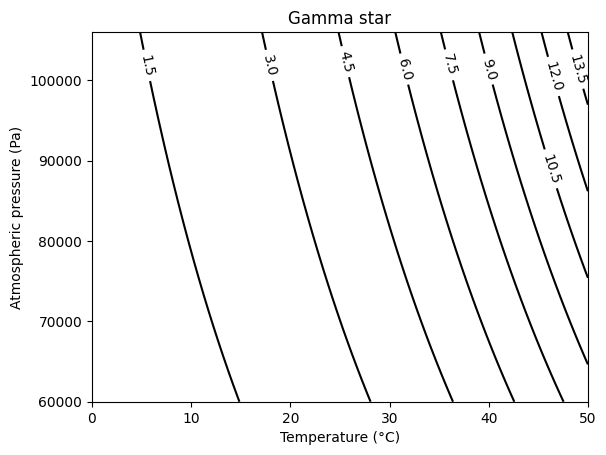

In [2]:
# Calculate gammastar
gammastar = calc_gammastar(tk=tk_2d, patm=patm_2d.transpose())

# Create a contour plot of gamma
fig, ax = pyplot.subplots()
CS = ax.contour(tc_1d, patm_1d, gammastar, levels=10, colors="black")
ax.clabel(CS, inline=1, fontsize=10)
ax.set_title("Gamma star")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Atmospheric pressure (Pa)")
pyplot.show()

## Michaelis-Menten coefficient for photosynthesis ($K_{mm}$)

The Michaelis-Menten coefficient for photosynthesis ($K_{mm}$) also varies with
temperature and atmospheric pressure:

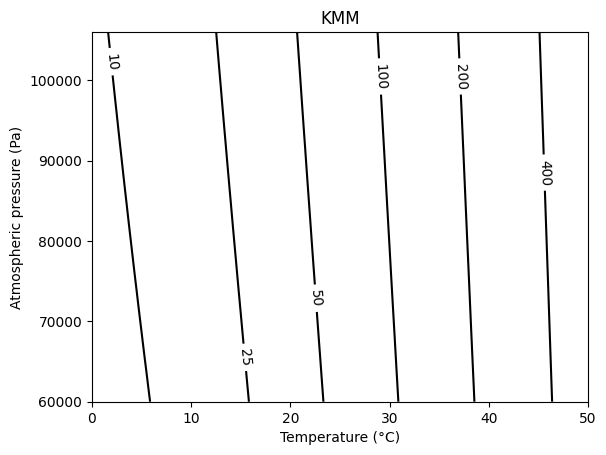

In [3]:
# Calculate K_mm
kmm = calc_kmm(tk=tk_2d, patm=patm_2d.transpose())

# Contour plot of calculated values
fig, ax = pyplot.subplots()
CS = ax.contour(tc_1d, patm_1d, kmm, levels=[10, 25, 50, 100, 200, 400], colors="black")
ax.clabel(CS, inline=1, fontsize=10)
ax.set_title("KMM")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Atmospheric pressure (Pa)")
pyplot.show()

## Relative viscosity of water ($\eta^*$)

The density ($\rho$) and viscosity ($\mu$) of water both vary with temperature
and atmospheric pressure. Together, these functions are used to calculate the
viscosity of water relative to its viscosity at standard temperature and
pressure ($\eta^*$).

The figure shows how $\eta^*$ varies with temperature and pressure.

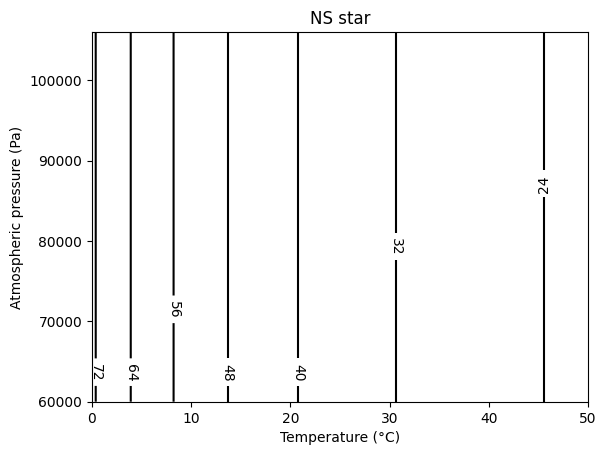

In [4]:
# Calculate the viscosity under the range of values and the standard
# temperature and pressure
viscosity = calc_viscosity_h2o(tc_2d, patm_2d.transpose())
viscosity_std = calc_viscosity_h2o(const.k_To, const.k_Po)

# Calculate the relative viscosity
ns_star = viscosity / viscosity_std

# Plot ns_star
fig, ax = pyplot.subplots()
CS = ax.contour(tc_1d, patm_1d, ns_star, colors="black")
ax.clabel(CS, inline=1, fontsize=10)
ax.set_title("NS star")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Atmospheric pressure (Pa)")
pyplot.show()

## Partial pressure of $\ce{CO2}$ ($c_a$)

The partial pressure of $\ce{CO2}$ is a function of the atmospheric concentration of
$\ce{CO2}$ in parts per million and the atmospheric pressure:

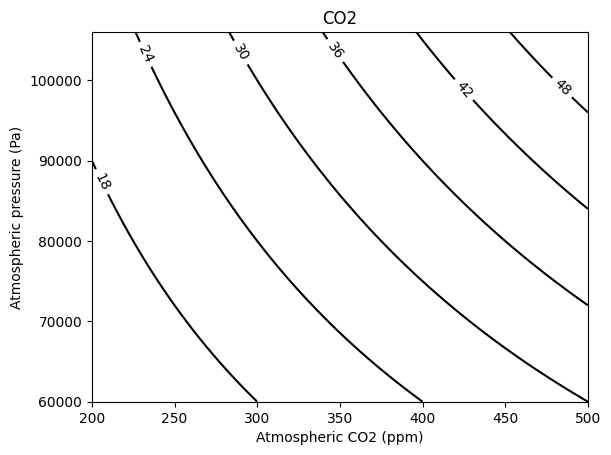

In [5]:
# Variation in partial pressure
ca = calc_co2_to_ca(co2_2d, patm_2d.transpose())
# Plot contour plot of values
fig, ax = pyplot.subplots()
CS = ax.contour(co2_1d, patm_1d, ca, colors="black")
ax.clabel(CS, inline=1, fontsize=10)
ax.set_title("CO2")
ax.set_xlabel("Atmospheric CO2 (ppm)")
ax.set_ylabel("Atmospheric pressure (Pa)")
pyplot.show()

## Absorbed irradiation ($I_{abs}$)

This value is simply the product of FAPAR and PPFD.
